Datos: 160 filas, 5 columnas

Muestras de datos originales:
anio_inicio (5 ejemplos): [2016, 2016, 2016, 2016, 2016]
tasa de delitos (5 ejemplos): ['10,6151055605904', '11,7303809378814', '9,47449702263931', '11,1980976408243', '8,8930609421704']
Se eliminaron 16 valores nulos

Después de limpieza básica:
anio_inicio (5 ejemplos): ['2016', '2016', '2016', '2016', '2016']
tasa de delitos (5 ejemplos): ['10.6151055605904', '11.7303809378814', '9.47449702263931', '11.1980976408243', '8.8930609421704']
Valores numéricos válidos después de conversión:
anio_inicio: 144 de 144
tasa de delitos: 144 de 144

 Análisis descriptivo:
   • Años: 2016 - 2024
   • Alcaldías: 16
   • Total observaciones: 144
   • Rango homicidios: 6.37955989011208 - 32.4004245572873
ANÁLISIS NO PARAMÉTRICO

 Análisis exploratorio

 Estadísticas por Alcaldía:
                        count   mean  median   std    min    max     sum  skew
alcaldia_hecho                                                                
ALVAR

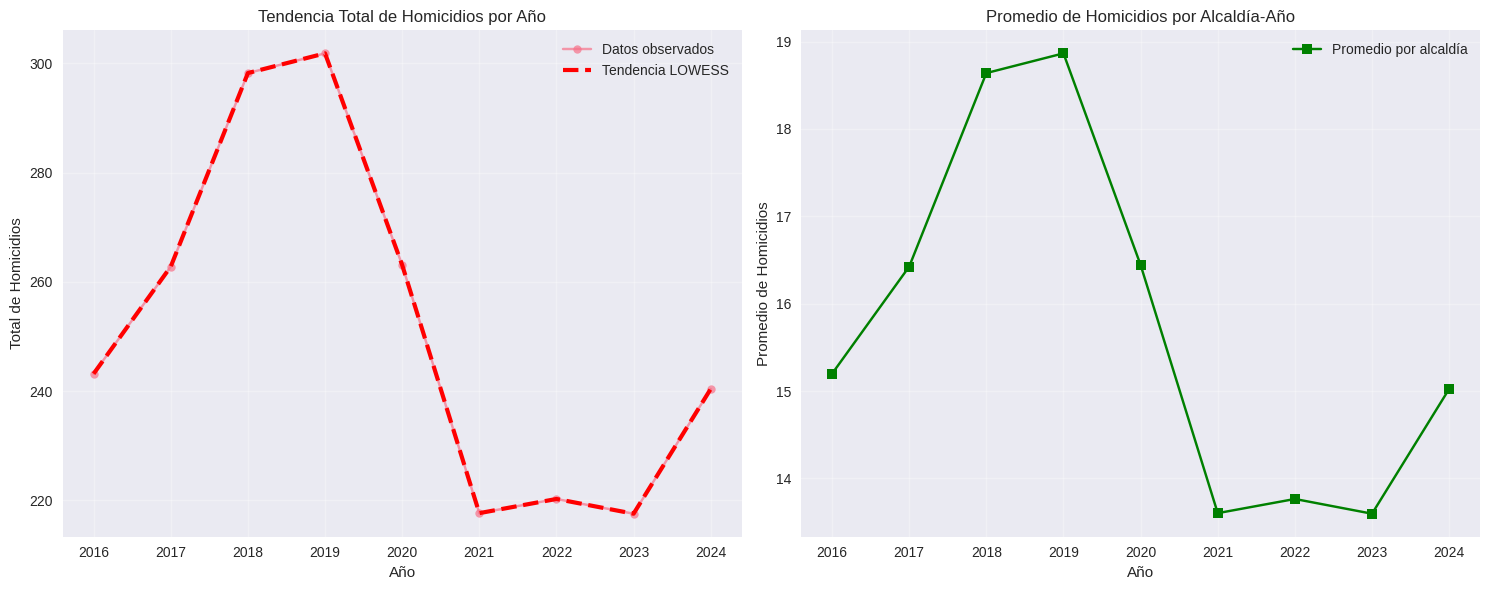

 Análisis de Tendencia LOWESS:
   Valor inicial: 243.2
   Valor final: 240.4
   Cambio relativo: -1.1%

 BOOTSTRAP (n=1000)
 Mediana General:
   Observada: 15.03
   IC 95%: (13.99, 15.82)

 Medianas por Alcaldía (Top 5):
 Error durante el análisis: Unknown format code 'd' for object of type 'float'
 Error crítico: Unknown format code 'd' for object of type 'float'

 Sugerencia: Verifica que el archivo exista y tenga las columnas correctas:
   - anio_inicio
   - alcaldia_hecho
   - tasa de delitos


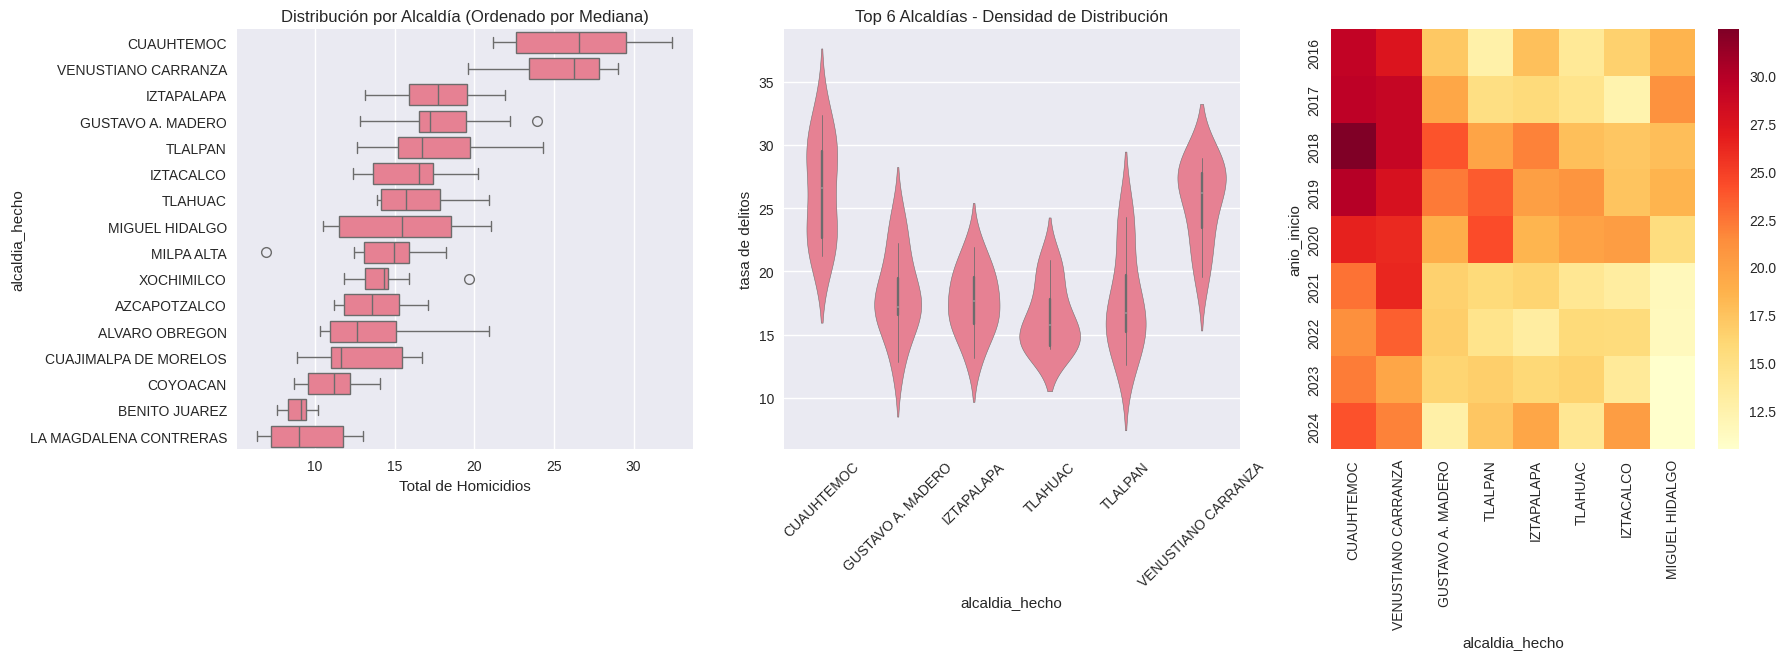

In [2]:
# Análisis No Paramétrico de Homicidios en CDMX por Alcaldía y Año
# ===============================================================================
# Este script presenta un análisis estadístico no paramétrico de homicidios
# por alcaldía y año.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (mannwhitneyu, kruskal, friedmanchisquare,
                        spearmanr, kendalltau, shapiro, levene, jarque_bera)
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class AnalisisNoParametrico:
        
    def __init__(self, archivo_datos):
        self.df = self._cargar_y_validar_datos(archivo_datos)
        self.resultados = {}
        
    def _cargar_y_validar_datos(self, archivo):
        try:
            df = pd.read_csv(archivo)
            print(f"Datos: {df.shape[0]} filas, {df.shape[1]} columnas")
        except FileNotFoundError:
            raise FileNotFoundError(f"no hya archivo: {archivo}")
        except Exception as e:
            raise Exception(f"error al cargar datos: {str(e)}")
        
        #columnas esperadas
        columnas_requeridas = ['anio_inicio', 'alcaldia_hecho', 'tasa de delitos']
        columnas_faltantes = [col for col in columnas_requeridas if col not in df.columns]
        
        if columnas_faltantes:
            print(f"Columnas disponibles: {list(df.columns)}")
            raise ValueError(f"Faltan columnas: {columnas_faltantes}")
        
        # Limpiar y convertir datos
        df = self._limpiar_datos(df)
        return df
    
    def _limpiar_datos(self, df):
        df_clean = df.copy()
        antes = len(df_clean)
    
        # Primero, mostrar ejemplos de las columnas para diagnóstico
        print("\nMuestras de datos originales:")
        print("anio_inicio (5 ejemplos):", df_clean['anio_inicio'].head().tolist())
        print("tasa de delitos (5 ejemplos):", df_clean['tasa de delitos'].head().tolist())
    
        # Eliminar filas con valores completamente nulos
        df_clean = df_clean.dropna(subset=['anio_inicio', 'alcaldia_hecho', 'tasa de delitos'])
        despues = len(df_clean)
        if antes != despues:
            print(f"Se eliminaron {antes-despues} valores nulos")
    
        # Limpieza agresiva de datos para asegurar formato numérico
        # 1. Para anio_inicio - extraer solo dígitos y convertir
        df_clean['anio_inicio'] = df_clean['anio_inicio'].astype(str).str.extract('(\d{4})').iloc[:,0]
    
        # 2. Para tasa de delitos - reemplazar comas por puntos y eliminar caracteres no numéricos
        df_clean['tasa de delitos'] = df_clean['tasa de delitos'].astype(str).str.replace(',', '.').str.replace(r'[^\d.]', '', regex=True)
    
        print("\nDespués de limpieza básica:")
        print("anio_inicio (5 ejemplos):", df_clean['anio_inicio'].head().tolist())
        print("tasa de delitos (5 ejemplos):", df_clean['tasa de delitos'].head().tolist())
    
        # Convertir a numérico después de limpieza
        df_clean["anio_inicio"] = pd.to_numeric(df_clean['anio_inicio'], errors='coerce')
        df_clean["tasa de delitos"] = pd.to_numeric(df_clean['tasa de delitos'], errors='coerce')
    
        # Reportar cuántos valores se convirtieron exitosamente
        print(f"Valores numéricos válidos después de conversión:")
        print(f"anio_inicio: {df_clean['anio_inicio'].notna().sum()} de {len(df_clean)}")
        print(f"tasa de delitos: {df_clean['tasa de delitos'].notna().sum()} de {len(df_clean)}")
    
        # Eliminar filas con valores NA después de la conversión
        antes_na = len(df_clean)
        df_clean = df_clean.dropna(subset=['anio_inicio', 'tasa de delitos'])
        despues_na = len(df_clean)
        if antes_na != despues_na:
            print(f"Se eliminaron {antes_na-despues_na} registros con valores no numéricos")
    
        # Si no quedan registros, mostrar advertencia clara y detener el proceso
        if len(df_clean) == 0:
            print("\n⚠️ ERROR CRÍTICO: Todos los registros fueron eliminados durante la limpieza")
            print("Verifique el formato de sus datos. Posibles problemas:")
            print("1. Los valores en 'anio_inicio' no contienen años de 4 dígitos")
            print("2. Los valores en 'tasa de delitos' tienen un formato no reconocible")
            print("\nSe recomienda abrir el archivo CSV directamente en un editor de texto")
            print("para verificar el formato real de los datos.")
            # No lanzar excepción aquí, solo retornar el DataFrame vacío
        else:
            # Continuar con el procesamiento normal si quedan registros
            df_clean["anio_inicio"] = df_clean["anio_inicio"].astype(int)
            df_clean["alcaldia_hecho"] = df_clean["alcaldia_hecho"].astype(str).str.upper().str.strip()
        
            # Filtrar por valores válidos y rango de años
            df_clean = df_clean[df_clean["tasa de delitos"] >= 0]
        
            antes_filtro = len(df_clean)
            df_clean = df_clean[(df_clean["anio_inicio"] >= 2016) & (df_clean["anio_inicio"] <= 2024)]
            despues_filtro = len(df_clean)
            if antes_filtro != despues_filtro:
                print(f"Se eliminaron {antes_filtro-despues_filtro} registros fuera del rango 2016-2024")
        
            # Mostrar estadísticas básicas
            print("\n Análisis descriptivo:")
            print(f"   • Años: {df_clean['anio_inicio'].min()} - {df_clean['anio_inicio'].max()}")
            print(f"   • Alcaldías: {df_clean['alcaldia_hecho'].nunique()}")
            print(f"   • Total observaciones: {len(df_clean)}")
            print(f"   • Rango homicidios: {df_clean['tasa de delitos'].min()} - {df_clean['tasa de delitos'].max()}")
    
        return df_clean
    
    def analisis_exploratorio(self):
        print("\n Análisis exploratorio")
        print("=" * 70)
        
        print("\n Estadísticas por Alcaldía:")
        stats_alcaldia = self.df.groupby('alcaldia_hecho')['tasa de delitos'].agg([
            'count', 'mean', 'median', 'std', 'min', 'max', 'sum', 'skew'
        ]).round(2)
        print(stats_alcaldia)
        
        print("\n Estadísticas por Año:")
        stats_anio = self.df.groupby('anio_inicio')['tasa de delitos'].agg([
            'count', 'sum', 'mean', 'median', 'std'
        ]).round(2)
        print(stats_anio)
        
        return stats_alcaldia, stats_anio
    
    def verificar_supuestos(self):
        print("\n VERIFICACIÓN DE SUPUESTOS (normalidad y heterocedasticidad)")
        print("=" * 70)
        
        # Test de normalidad por alcaldía
        print("\n Prueba de normalidad por Alcaldía:")
        normalidad_resultados = {}
        
        for alcaldia in self.df['alcaldia_hecho'].unique():
            datos = self.df[self.df['alcaldia_hecho'] == alcaldia]['tasa de delitos']
            if len(datos) >= 3:  # Mínimo para tests
                # Shapiro-Wilk
                stat_sw, p_sw = shapiro(datos)
                # Jarque-Bera
                stat_jb, p_jb = jarque_bera(datos)
                
                normalidad_resultados[alcaldia] = {
                    'n': len(datos),
                    'shapiro_p': p_sw,
                    'jarque_bera_p': p_jb,
                    'normal': p_sw > 0.05 and p_jb > 0.05
                }
                
                print(f"   {alcaldia:15} (n={len(datos):2d}): "
                      f"Shapiro p={p_sw:.4f}, JB p={p_jb:.4f} "
                      f"{'✅' if p_sw > 0.05 and p_jb > 0.05 else '❌'}")
        
        #prueba de homocedasticidad (Levene)
        grupos = [grupo['tasa de delitos'].values for _, grupo in self.df.groupby('alcaldia_hecho') 
                 if len(grupo) >= 3]
        
        if len(grupos) >= 2:
            stat_levene, p_levene = levene(*grupos)
            print(f"\n Prueba de Levene (homocedasticidad): p={p_levene:.6f} "
                  f"{'✅' if p_levene > 0.05 else '❌'}")
            
            # Justificación para métodos no paramétricos
            no_normal = sum(1 for r in normalidad_resultados.values() if not r['normal'])
            total_grupos = len(normalidad_resultados)
            
            print(f"\n JUSTIFICACIÓN MÉTODOS NO PARAMÉTRICOS:")
            print(f"   • {no_normal}/{total_grupos} grupos no siguen distribución normal")
            print(f"   • Homocedasticidad: {'No se cumple' if p_levene <= 0.05 else 'Se cumple'}")
            print("   ✅ Métodos no paramétricos son apropiados")
        
        return normalidad_resultados
    
    def pruebas_comparacion(self):
        print("\n PRUEBAS DE COMPARACIÓN NO PARAMÉTRICAS")
        print("=" * 50)
        
        # Kruskal-Wallis
        grupos = [grupo["tasa de delitos"].values for _, grupo in self.df.groupby("alcaldia_hecho") 
                 if len(grupo) >= 3]
        nombres_grupos = [nombre for nombre, grupo in self.df.groupby("alcaldia_hecho") 
                         if len(grupo) >= 3]
        
        if len(grupos) >= 2:
            h_stat, p_kruskal = kruskal(*grupos)
            print(f"\n Kruskal-Wallis:")
            print(f"   H = {h_stat:.4f}")
            print(f"   p-valor = {p_kruskal:.6f}")
            print(f"   Interpretación: {'Hay diferencias significativas' if p_kruskal < 0.05 else 'No hay diferencias significativas'}")
            
            self.resultados['kruskal_wallis'] = {
                'statistic': h_stat,
                'p_value': p_kruskal,
                'significativo': p_kruskal < 0.05
            }
            
            # Comparaciones post-hoc si es significativo
            if p_kruskal < 0.05:
                print(f"\n Comparaciones Mann-Whitney:")
                self._comparaciones_posthoc(nombres_grupos)
        
        # Friedman (si hay datos longitudinales)
        self._prueba_friedman()
        
    def _comparaciones_posthoc(self, nombres_grupos):
        from itertools import combinations
        
        comparaciones = []
        for alcaldia1, alcaldia2 in combinations(nombres_grupos, 2):
            grupo1 = self.df[self.df["alcaldia_hecho"] == alcaldia1]["tasa de delitos"]
            grupo2 = self.df[self.df["alcaldia_hecho"] == alcaldia2]["tasa de delitos"]
            
            if len(grupo1) >= 3 and len(grupo2) >= 3:
                u_stat, p_valor = mannwhitneyu(grupo1, grupo2, alternative='two-sided')
                comparaciones.append({
                    'grupo1': alcaldia1,
                    'grupo2': alcaldia2,
                    'u_statistic': u_stat,
                    'p_valor': p_valor,
                    'significativo': p_valor < 0.05
                })
        
        # Mostrar solo las más significativas
        comparaciones_sig = [c for c in comparaciones if c['significativo']]
        comparaciones_sig.sort(key=lambda x: x['p_valor'])
        
        print(f"   Total comparaciones: {len(comparaciones)}")
        print(f"   Significativas (p<0.05): {len(comparaciones_sig)}")
        
        for comp in comparaciones_sig[:10]:  
            print(f"   {comp['grupo1']} vs {comp['grupo2']}: "
                  f"U={comp['u_statistic']:.1f}, p={comp['p_valor']:.4f} ⭐")
    
    def _prueba_friedman(self):
        """Realiza prueba de Friedman para medidas repetidas."""
        try:
            pivot = self.df.pivot(index="anio_inicio", columns="alcaldia_hecho", 
                                values="tasa de delitos").dropna(axis=1)
            
            if pivot.shape[1] >= 3 and pivot.shape[0] >= 3:
                columnas = [pivot[col] for col in pivot.columns]
                chi2_stat, p_friedman = friedmanchisquare(*columnas)
                
                print(f"\n Prueba de Friedman (tendencias temporales):")
                print(f"   Chi² = {chi2_stat:.4f}")
                print(f"   p-valor = {p_friedman:.6f}")
                print(f"   Interpretación: {'Hay diferencias en tendencias temporales' if p_friedman < 0.05 else 'No hay diferencias en tendencias temporales'}")
                
                self.resultados['friedman'] = {
                    'statistic': chi2_stat,
                    'p_value': p_friedman,
                    'significativo': p_friedman < 0.05
                }
        except Exception as e:
            print(f" fallo la prueba: {str(e)}")
    
    def analisis_correlacion(self):
        """Analiza correlaciones no paramétricas."""
        print("\n ANÁLISIS DE CORRELACIONES NO PARAMÉTRICAS")
        print("=" * 70)
        
        # Correlación general año-homicidios
        rho_spearman, p_spearman = spearmanr(self.df["anio_inicio"], self.df["tasa de delitos"])
        tau_kendall, p_kendall = kendalltau(self.df["anio_inicio"], self.df["tasa de delitos"])
        
        print(f"\n Correlación Temporal (Año vs Total Homicidios):")
        print(f"   Spearman ρ = {rho_spearman:.4f}, p = {p_spearman:.6f}")
        print(f"   Kendall τ = {tau_kendall:.4f}, p = {p_kendall:.6f}")
        
        # Interpretación
        if abs(rho_spearman) < 0.3:
            fuerza = "débil"
        elif abs(rho_spearman) < 0.7:
            fuerza = "moderada"
        else:
            fuerza = "fuerte"
        
        direccion = "positiva" if rho_spearman > 0 else "negativa"
        print(f"   Interpretación: Correlación {fuerza} {direccion}")
        
        self.resultados['correlaciones'] = {
            'spearman_rho': rho_spearman,
            'spearman_p': p_spearman,
            'kendall_tau': tau_kendall,
            'kendall_p': p_kendall
        }
    
    def analisis_tendencias(self, frac=0.4):
        """Análisis de tendencias con LOWESS."""
        print("\n ANÁLISIS DE TENDENCIAS")
        print("=" * 70)
        
        # Agregación por año
        data_agg = self.df.groupby("anio_inicio")["tasa de delitos"].agg(['sum', 'mean', 'count']).reset_index()
        
        # LOWESS smoothing
        suavizado = lowess(data_agg["sum"], data_agg["anio_inicio"], frac=frac)
        
        # Visualización
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Tendencia general
        ax1.plot(data_agg["anio_inicio"], data_agg["sum"], 'o-', 
                label="Datos observados", alpha=0.7, markersize=6)
        ax1.plot(suavizado[:, 0], suavizado[:, 1], 'r--', 
                linewidth=3, label="Tendencia LOWESS")
        ax1.set_title("Tendencia Total de Homicidios por Año")
        ax1.set_xlabel("Año")
        ax1.set_ylabel("Total de Homicidios")
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Promedio por alcaldía-año
        ax2.plot(data_agg["anio_inicio"], data_agg["mean"], 's-', 
                color='green', label="Promedio por alcaldía")
        ax2.set_title("Promedio de Homicidios por Alcaldía-Año")
        ax2.set_xlabel("Año")
        ax2.set_ylabel("Promedio de Homicidios")
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Análisis de la tendencia
        tendencia_inicial = suavizado[0, 1]
        tendencia_final = suavizado[-1, 1]
        cambio_relativo = ((tendencia_final - tendencia_inicial) / tendencia_inicial) * 100
        
        print(f" Análisis de Tendencia LOWESS:")
        print(f"   Valor inicial: {tendencia_inicial:.1f}")
        print(f"   Valor final: {tendencia_final:.1f}")
        print(f"   Cambio relativo: {cambio_relativo:+.1f}%")
    
    def bootstrap_intervalos(self, n_iter=1000, ci=95):
        print(f"\n BOOTSTRAP (n={n_iter})")
        print("=" * 50)
        
        # Bootstrap para mediana general
        medianas = [np.median(resample(self.df["tasa de delitos"], random_state=i)) 
                   for i in range(n_iter)]
        
        lower = np.percentile(medianas, (100 - ci) / 2)
        upper = np.percentile(medianas, 100 - (100 - ci) / 2)
        mediana_observada = np.median(self.df["tasa de delitos"])
        
        print(f" Mediana General:")
        print(f"   Observada: {mediana_observada:.2f}")
        print(f"   IC {ci}%: ({lower:.2f}, {upper:.2f})")
        
        # Bootstrap por alcaldía (top 5)
        top_alcaldias = self.df.groupby('alcaldia_hecho')['tasa de delitos'].sum().nlargest(5).index
        
        print(f"\n Medianas por Alcaldía (Top 5):")
        for alcaldia in top_alcaldias:
            datos = self.df[self.df['alcaldia_hecho'] == alcaldia]['tasa de delitos']
            if len(datos) >= 10:  # Mínimo para bootstrap confiable
                medianas_boot = [np.median(resample(datos, random_state=i)) 
                               for i in range(n_iter)]
                lower_alc = np.percentile(medianas_boot, (100 - ci) / 2)
                upper_alc = np.percentile(medianas_boot, 100 - (100 - ci) / 2)
                mediana_obs = np.median(datos)
                
                print(f"   {alcaldia:15}: {mediana_obs:.1f} IC({lower_alc:.1f}, {upper_alc:.1f})")
    
    def visualizaciones_avanzadas(self):
        
        fig = plt.figure(figsize=(20, 12))
        
        # 1. Boxplot comparativo
        ax1 = plt.subplot(2, 3, 1)
        sns.boxplot(data=self.df, y="alcaldia_hecho", x="tasa de delitos", 
                   order=self.df.groupby('alcaldia_hecho')['tasa de delitos'].median().sort_values(ascending=False).index)
        plt.title("Distribución por Alcaldía (Ordenado por Mediana)")
        plt.xlabel("Total de Homicidios")
        
        # 2. Violin plot
        ax2 = plt.subplot(2, 3, 2)
        top_6_alcaldias = self.df.groupby('alcaldia_hecho')['tasa de delitos'].sum().nlargest(6).index
        df_top6 = self.df[self.df['alcaldia_hecho'].isin(top_6_alcaldias)]
        sns.violinplot(data=df_top6, x="alcaldia_hecho", y="tasa de delitos", inner="box")
        plt.xticks(rotation=45)
        plt.title("Top 6 Alcaldías - Densidad de Distribución")
        
        # 3. Heatmap temporal
        ax3 = plt.subplot(2, 3, 3)
        pivot_heatmap = self.df.pivot_table(values='tasa de delitos', 
                                          index='anio_inicio', 
                                          columns='alcaldia_hecho', 
                                          aggfunc='sum', fill_value=0)
        # Solo top alcaldías para legibilidad
        top_cols = pivot_heatmap.sum().nlargest(8).index
        sns.heatmap(pivot_heatmap[top_cols], annot=True, fmt='d', cmap='YlOrRd')
        plt.title("Mapa de Calor: Homicidios por Año y Alcaldía")
        
        # 4. Serie temporal con bandas de confianza
        ax4 = plt.subplot(2, 3, 4)
        data_anual = self.df.groupby("anio_inicio")["tasa de delitos"].agg(['sum', 'std', 'count']).reset_index()
        data_anual['se'] = data_anual['std'] / np.sqrt(data_anual['count'])
        
        plt.plot(data_anual["anio_inicio"], data_anual["sum"], 'o-', linewidth=2)
        plt.fill_between(data_anual["anio_inicio"], 
                        data_anual["sum"] - 1.96*data_anual['se'],
                        data_anual["sum"] + 1.96*data_anual['se'], 
                        alpha=0.3)
        plt.title("Serie Temporal con Intervalos de Confianza")
        plt.xlabel("Año")
        plt.ylabel("Total Homicidios")
        
        # 5. Distribución general
        ax5 = plt.subplot(2, 3, 5)
        plt.hist(self.df["tasa de delitos"], bins=30, alpha=0.7, density=True)
        plt.axvline(np.mean(self.df["tasa de delitos"]), color='red', 
                   linestyle='--', label=f'Media: {np.mean(self.df["tasa de delitos"]):.1f}')
        plt.axvline(np.median(self.df["tasa de delitos"]), color='green', 
                   linestyle='--', label=f'Mediana: {np.median(self.df["tasa de delitos"]):.1f}')
        plt.title("Distribución General de Homicidios")
        plt.xlabel("Total de Homicidios")
        plt.ylabel("Densidad")
        plt.legend()
        
        # 6. Ranking de alcaldías
        ax6 = plt.subplot(2, 3, 6)
        ranking = self.df.groupby('alcaldia_hecho')['tasa de delitos'].agg(['sum', 'mean']).sort_values('sum', ascending=True)
        y_pos = np.arange(len(ranking))
        plt.barh(y_pos, ranking['sum'], alpha=0.7)
        plt.yticks(y_pos, ranking.index)
        plt.title("Ranking Total de Homicidios por Alcaldía")
        plt.xlabel("Total Acumulado")
        
        plt.tight_layout()
        plt.show()
    
    def generar_reporte_completo(self):
        """Genera un reporte completo del análisis."""
        print("\n📋 REPORTE EJECUTIVO - ANÁLISIS NO PARAMÉTRICO")
        print("=" * 70)
        
        # Estadísticas generales
        total_homicidios = self.df['tasa de delitos'].sum()
        alcaldias_unicas = self.df['alcaldia_hecho'].nunique()
        anios_unicas = self.df['anio_inicio'].nunique()
        
        print(f"\n RESUMEN EJECUTIVO:")
        print(f"   • Total de homicidios analizados: {total_homicidios:,}")
        print(f"   • Alcaldías incluidas: {alcaldias_unicas}")
        print(f"   • Período analizado: {anios_unicas} años")
        print(f"   • Promedio por observación: {self.df['tasa de delitos'].mean():.1f}")
        print(f"   • Mediana por observación: {self.df['tasa de delitos'].median():.1f}")
        
        # Top y bottom alcaldías
        ranking_total = self.df.groupby('alcaldia_hecho')['tasa de delitos'].sum().sort_values(ascending=False)
        print(f"\n TOP 3 ALCALDÍAS (Total):")
        for i, (alcaldia, total) in enumerate(ranking_total.head(3).items(), 1):
            pct = (total/total_homicidios)*100
            print(f"   {i}. {alcaldia}: {total:,} ({pct:.1f}%)")
        
        print(f"\n MENOR INCIDENCIA (Total):")
        for i, (alcaldia, total) in enumerate(ranking_total.tail(3).items(), 1):
            pct = (total/total_homicidios)*100
            print(f"   {i}. {alcaldia}: {total:,} ({pct:.1f}%)")
        
        # Resultados de pruebas estadísticas
        print(f"\n RESULTADOS DE PRUEBAS ESTADÍSTICAS:")
        if 'kruskal_wallis' in self.resultados:
            kw = self.resultados['kruskal_wallis']
            print(f"   • Kruskal-Wallis: {'Diferencias significativas' if kw['significativo'] else 'Sin diferencias'} "
                  f"(p={kw['p_value']:.4f})")
        
        if 'correlaciones' in self.resultados:
            corr = self.resultados['correlaciones']
            print(f"   • Correlación temporal: ρ={corr['spearman_rho']:.3f} "
                  f"({'significativa' if corr['spearman_p'] < 0.05 else 'no significativa'})")
        
        print(f"\n✅ ANÁLISIS COMPLETADO EXITOSAMENTE")

    #ejecución del pipeline completo    
    def ejecutar_analisis_completo(self):
        print("=" * 70)
        print("ANÁLISIS NO PARAMÉTRICO")
        print("=" * 70)
        
        try:
            self.analisis_exploratorio()
            self.verificar_supuestos()
            self.pruebas_comparacion()
            self.analisis_correlacion()
            self.analisis_tendencias()
            self.bootstrap_intervalos()
            self.visualizaciones_avanzadas()
            self.generar_reporte_completo()
            
        except Exception as e:
            print(f" Error durante el análisis: {str(e)}")
            raise

# ================================
# EJECUCIÓN PRINCIPAL
# ================================

if __name__ == "__main__":
    ARCHIVO_DATOS = "/home/adonnay_bazaldua/Documentos/GitHub/Nonparametric-analysis-of-homicides-in-CDMX-by-borough/data/processed//dataframe.csv" 
    
    try:
        analisis = AnalisisNoParametrico(ARCHIVO_DATOS)
        
        analisis.ejecutar_analisis_completo()
        
    except Exception as e:
        print(f" Error crítico: {str(e)}")
        print("\n Sugerencia: Verifica que el archivo exista y tenga las columnas correctas:")
        print("   - anio_inicio")
        print("   - alcaldia_hecho") 
        print("   - tasa de delitos")